# Final Assignment: training

This notebook contains the source code for training the weights of the classification model.

## Download dataset

The following cell needs to be ran only once. It downloads and unzips the data. The unzip CLI tool might not be installed by default on Windows, so if you are using windows, please unzip manually into a folder called "data", or see the README.md.

In [1]:
# Downloading the dataset (unzip might not be installed on Windows)
!curl -L -o ./data.zip https://www.kaggle.com/api/v1/datasets/download/masoudnickparvar/brain-tumor-mri-dataset
!unzip -d ./data ./data.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  157M  100  157M    0     0  20.6M      0  0:00:07  0:00:07 --:--:-- 21.6M
Archive:  ./data.zip
  inflating: ./data/Testing/glioma/Te-gl_1.jpg  
  inflating: ./data/Testing/glioma/Te-gl_10.jpg  
  inflating: ./data/Testing/glioma/Te-gl_100.jpg  
  inflating: ./data/Testing/glioma/Te-gl_101.jpg  
  inflating: ./data/Testing/glioma/Te-gl_102.jpg  
  inflating: ./data/Testing/glioma/Te-gl_103.jpg  
  inflating: ./data/Testing/glioma/Te-gl_104.jpg  
  inflating: ./data/Testing/glioma/Te-gl_105.jpg  
  inflating: ./data/Testing/glioma/Te-gl_106.jpg  
  inflating: ./data/Testing/glioma/Te-gl_107.jpg  
  inflating: ./data/Testing/glioma/Te-gl_108.jpg  
  inflating: ./data/Testing/glioma/Te-gl_109.jpg  
  inflating: ./data/Testing/glioma/Te-gl_11.jpg  
  in

## Importing libraries

See README.md for installing dependencies :).

In [2]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torch.optim import Adam
from torchvision import models, datasets, transforms
from sklearn.metrics import balanced_accuracy_score
from tqdm import tqdm

## Setting the seed

Setting the seed for good reproducability :D

In [3]:
torch.manual_seed(21)  # Using my lucky number :D
np.random.seed(21)

## Setting the device used for training

In [4]:
device = "cpu"
if torch.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
print(f"Using: {device}")

Using: mps


## Preparing the dataset

In [5]:
transform = transforms.Compose(
    [
        transforms.Resize((299, 299)),  # 299 is the minimal image size of InceptionV3
        transforms.ToTensor(),
        # transforms.Normalize(0.5, 0.5)
    ]
)

In [10]:
path = "data"
train_path = os.path.join(path, "Training")
test_path = os.path.join(path, "Testing")

In [11]:
train_dataset = datasets.ImageFolder(
    root=train_path,
    transform=transform
)
test_dataset = datasets.ImageFolder(
    root=test_path,
    transform=transform
)

In [12]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

## Creating the model

### Loading pre-trained model

In [13]:
model = models.inception_v3(weights=models.Inception_V3_Weights)

/Users/daanwichmann/PycharmProjects/Explainable AI/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Adding custom classification head

In [17]:
# Got the number of input features from the sourcecode hihi
# There are 4 output features, equal to the number of classes
model.fc = nn.Linear(in_features=2048, out_features=4)

In [18]:
model = model.to(device)

### Freezing layers

In [19]:
for name, param in model.named_parameters():
    if "Conv2d" in name or "Mixed_5" in name:
        print(f"Froze layer {name}")
        param.requires_grad = False  # Setting requires_grad to False, makes it so the gradient can't be computed, and the optimizers won't update the parameters.

Froze layer Conv2d_1a_3x3.conv.weight
Froze layer Conv2d_1a_3x3.bn.weight
Froze layer Conv2d_1a_3x3.bn.bias
Froze layer Conv2d_2a_3x3.conv.weight
Froze layer Conv2d_2a_3x3.bn.weight
Froze layer Conv2d_2a_3x3.bn.bias
Froze layer Conv2d_2b_3x3.conv.weight
Froze layer Conv2d_2b_3x3.bn.weight
Froze layer Conv2d_2b_3x3.bn.bias
Froze layer Conv2d_3b_1x1.conv.weight
Froze layer Conv2d_3b_1x1.bn.weight
Froze layer Conv2d_3b_1x1.bn.bias
Froze layer Conv2d_4a_3x3.conv.weight
Froze layer Conv2d_4a_3x3.bn.weight
Froze layer Conv2d_4a_3x3.bn.bias
Froze layer Mixed_5b.branch1x1.conv.weight
Froze layer Mixed_5b.branch1x1.bn.weight
Froze layer Mixed_5b.branch1x1.bn.bias
Froze layer Mixed_5b.branch5x5_1.conv.weight
Froze layer Mixed_5b.branch5x5_1.bn.weight
Froze layer Mixed_5b.branch5x5_1.bn.bias
Froze layer Mixed_5b.branch5x5_2.conv.weight
Froze layer Mixed_5b.branch5x5_2.bn.weight
Froze layer Mixed_5b.branch5x5_2.bn.bias
Froze layer Mixed_5b.branch3x3dbl_1.conv.weight
Froze layer Mixed_5b.branch3x3d

## Training the model

### Function for calculating the models accuracy

In [20]:
def balanced_accuracy(model: nn.Module, loader: DataLoader) -> float:
    model.eval()  # Sets model to evaluation mode
    running_balanced_acc = 0

    for X, y in loader:

        X, y = X.to(device), y.to(device)

        with torch.no_grad():
            y_pred = model(X)
            y_pred = torch.argmax(y_pred, dim=-1)

        y, y_pred = y.to("cpu"), y_pred.to("cpu")  # Moving data back to CPU for sklearn

        fraction = len(y_pred) / len(loader.dataset)
        running_balanced_acc += balanced_accuracy_score(y, y_pred) * fraction

    return running_balanced_acc

### Setting hyper parameters

In [21]:
EPOCHS = 50
LR = 1e-6
WEIGHTS_PATH = "weights"

### Initializing optimizer and loss function

In [22]:
optimizer = Adam(params=model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss().to(device)

### Printing initial accuracy

In [46]:
print(f"Balanced test accuracy {balanced_accuracy(model, test_loader) * 100:.2f}%")

Balanced test accuracy 47.49%


### Training Loop

In [16]:
for epoch in range(EPOCHS):

    model.train()  # Setting the model to training mode
    running_loss = 0


    for X, y in tqdm(train_loader, f"Epoch {epoch +1}"):
        X, y = X.to(device), y.to(device)

        y_pred = model(X)[0]
        loss = criterion(y_pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    running_loss /= len(train_loader)
    balanced_acc = balanced_accuracy(model, test_loader)

    path = os.path.join("weights", f"model-{balanced_acc*100:.0f}.pth")
    torch.save(model.state_dict(), path)

    print(f"Epoch complete: {epoch + 1}/{EPOCHS} (loss: {running_loss})")
    print(f"Balanced test accuracy {balanced_acc * 100:.2f}%")

Epoch 1: 100%|██████████| 13/13 [00:08<00:00,  1.50it/s]


Epoch complete: 1/50 (loss: 0.6965526067293607)
Balanced test accuracy 44.66%


Epoch 2: 100%|██████████| 13/13 [00:05<00:00,  2.21it/s]


Epoch complete: 2/50 (loss: 0.7123242754202622)
Balanced test accuracy 51.95%


Epoch 3:  38%|███▊      | 5/13 [00:02<00:04,  1.94it/s]


KeyboardInterrupt: 

## Inspecting results

### Creating dictionary for label names

In [47]:
LABELS = {
    0: "NO TUMOR",
    1: "TUMOR",
}

### Loading model parameters

In [48]:
path = os.path.join("weights", "model-91.pth")
model.load_state_dict(torch.load(path, map_location=device))

<All keys matched successfully>

### Inspecting examples

Predicted: TUMOR
Actual: TUMOR


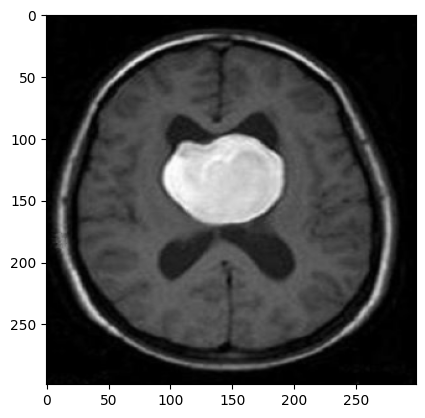

In [67]:
model.eval()

X, y = next(iter(test_loader))
X_device = X.to(device)
y_pred = torch.argmax(model(X_device), dim=1)

i = 0  # Change this variable to look at different images

print(f"Predicted: {LABELS[y_pred[i].item()]}")
print(f"Actual: {LABELS[y[i].item()]}")

image = X[i].permute((1, 2, 0))
plt.imshow(image)
plt.show()